# 📌 Cell 1: Cài đặt Thư viện & Kiểm tra GPU

In [1]:
# Cell 1: Thư viện
!pip install -q albumentations onnx onnxruntime onnxscript scikit-learn

import os, json, time, sys
import cv2
import numpy as np
torch_ver = ""
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision.models as models
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

try:
    import onnx
    import onnxruntime as ort
    ONNX_AVAILABLE = True
except ModuleNotFoundError:
    ONNX_AVAILABLE = False
    print("⚠️ Không tìm thấy onnx/onnxruntime.")

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 47.9 MB/s eta 0:00:0000:01:00:01
PyTorch Version: 2.10.0+cpu
CUDA Available: False


# 📌 Cell 2: Dataset Definition (CelebA-Spoof 3 class)

In [ ]:
class CelebASpoof3ClassDataset(Dataset):
    def __init__(self, root_dir, json_path, transform=None):
        self.root_dir = root_dir
        with open(json_path, 'r') as f:
            self.data = json.load(f)
        # danh sách các đường dẫn để truy cập
        self.keys = list(self.data.keys())
        self.transform = transform

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        rel_path = self.keys[idx]
        labels = self.data[rel_path]

        img_path = os.path.join(self.root_dir, rel_path)
        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h_img, w_img = image.shape[:2]

        # Đọc bbox từ file <img>_BB.txt riêng
        # Một số file _BB.txt trong dataset bị RỖNG hoặc thiếu đủ 4 giá trị -> phải kiểm tra
        # trước khi unpack, nếu không sẽ crash ValueError giữa lúc train (lỗi dữ liệu, không phải bug code).
        bb_path = os.path.splitext(img_path)[0] + "_BB.txt"
        if os.path.exists(bb_path):
            try:
                with open(bb_path, 'r') as f:
                    parts = f.readline().strip().split()
                if len(parts) >= 4:
                    x, y, w, h = map(float, parts[:4])
                    # Quy đổi từ hệ chuẩn hóa 224 -> pixel thật của ảnh
                    x = x / 224 * w_img
                    y = y / 224 * h_img
                    w = w / 224 * w_img
                    h = h / 224 * h_img

                    # Mở rộng khung x1.5 và đệm viền BORDER_REFLECT_101 giữ nguyên tỷ lệ vuông 1:1 đồng bộ với preprocess.py
                    max_dim = max(w, h)
                    cx, cy = x + w / 2, y + h / 2
                    crop_size = int(max_dim * 1.5)
                    
                    x_start = int(cx - crop_size / 2)
                    y_start = int(cy - crop_size / 2)
                    
                    crop_x1, crop_y1 = max(0, x_start), max(0, y_start)
                    crop_x2, crop_y2 = min(w_img, x_start + crop_size), min(h_img, y_start + crop_size)
                    
                    top_pad = int(max(0, -y_start))
                    left_pad = int(max(0, -x_start))
                    bottom_pad = int(max(0, (y_start + crop_size) - h_img))
                    right_pad = int(max(0, (x_start + crop_size) - w_img))
                    
                    if crop_x2 > crop_x1 and crop_y2 > crop_y1:
                        cropped_img = image[crop_y1:crop_y2, crop_x1:crop_x2, :]
                    else:
                        cropped_img = np.zeros((0, 0, 3), dtype=image.dtype)
                    
                    image = cv2.copyMakeBorder(cropped_img, top_pad, bottom_pad, left_pad, right_pad, cv2.BORDER_REFLECT_101)
                    if image.shape[0] != crop_size or image.shape[1] != crop_size:
                        image = cv2.resize(image, (crop_size, crop_size), interpolation=cv2.INTER_AREA)
            except (ValueError, OSError):
                pass


        label_raw = int(labels[40])   # ĐÃ XÁC NHẬN: index 40 = spoof type chi tiết
        
        if label_raw == 0:
            label = 0  # Real
        elif label_raw in [1, 2, 3, 4, 5, 6, 7]:
            label = 1  # Physical Spoof
        else:
            label = 2  # Digital Spoof

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(label, dtype=torch.long)

# 📌 Cell 3: Data Transforms & DataLoaders

In [ ]:
# Cell 3: Transforms & DataLoaders (ĐÃ TỐI ƯU)
CELEBA_MEAN = [0.5931, 0.4690, 0.4229]
CELEBA_STD = [0.2471, 0.2214, 0.2157]

# Data Augmentation
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    # Giả lập biến dạng màu và màn hình hiển thị
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    # Giả lập chất lượng camera khác nhau (quan trọng cho Cross-dataset)
    A.ImageCompression(quality_range=(50, 95), p=0.4),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.Affine(scale=(0.9, 1.1), rotate=(-15, 15), translate_percent=(-0.05, 0.05), p=0.4),
    # Ép mô hình nhìn tổng thể khuôn mặt, không bắt lỗi viền pixel
    A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32), hole_width_range=(16, 32), p=0.3),
    A.Normalize(mean=CELEBA_MEAN, std=CELEBA_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=CELEBA_MEAN, std=CELEBA_STD),
    ToTensorV2(),
])

DATA_ROOT = "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof"
TRAIN_JSON = os.path.join(DATA_ROOT, "metas/intra_test/train_label.json")
VAL_JSON = os.path.join(DATA_ROOT, "metas/intra_test/test_label.json")

print(f"Loading Train Metadata from: {TRAIN_JSON}")
print(f"Loading Val Metadata from: {VAL_JSON}")

train_dataset_full = CelebASpoof3ClassDataset(DATA_ROOT, TRAIN_JSON, transform=train_transform)
val_dataset = CelebASpoof3ClassDataset(DATA_ROOT, VAL_JSON, transform=val_transform)

# --- Giới hạn số lượng ảnh Train (tuỳ chọn) để rút ngắn thời gian train ---
# Đặt 1 số nguyên (vd 100000) để CHỈ dùng ngẫu nhiên từng đó ảnh trong tập train.
# Đặt None để dùng TOÀN BỘ tập train gốc (494K+ ảnh, rất lâu).
TRAIN_SAMPLE_SIZE = 100000
SAMPLE_SEED = 42  # cố định seed -> lấy mẫu giống nhau giữa các lần chạy/resume

def _label_of(v):
    lr = int(v[40])
    if lr == 0:
        return 0
    elif lr in [1, 2, 3, 4, 5, 6, 7]:
        return 1
    else:
        return 2

if TRAIN_SAMPLE_SIZE is not None and TRAIN_SAMPLE_SIZE < len(train_dataset_full):
    # Lấy mẫu CÓ PHÂN TẦNG theo class (Real/Physical/Digital) -> giữ đúng tỉ lệ như tập gốc,
    # thay vì random thuần có thể vô tình làm lệch/thiếu hẳn 1 class hiếm.
    rng = np.random.default_rng(SAMPLE_SEED)

    all_labels = np.empty(len(train_dataset_full), dtype=np.int64)
    for i, key in enumerate(train_dataset_full.keys):
        all_labels[i] = _label_of(train_dataset_full.data[key])

    selected_indices = []
    for c in [0, 1, 2]:
        class_indices = np.where(all_labels == c)[0]
        n_keep = int(round(TRAIN_SAMPLE_SIZE * len(class_indices) / len(train_dataset_full)))
        n_keep = min(n_keep, len(class_indices))
        chosen = rng.choice(class_indices, size=n_keep, replace=False)
        selected_indices.extend(chosen.tolist())

    rng.shuffle(selected_indices)
    train_dataset = torch.utils.data.Subset(train_dataset_full, selected_indices)
    print(f"--> Đã giới hạn tập Train: {len(train_dataset)}/{len(train_dataset_full)} ảnh "
          f"(giữ nguyên tỉ lệ 3 class, seed={SAMPLE_SEED})")
else:
    train_dataset = train_dataset_full
    print(f"--> Dùng TOÀN BỘ tập Train: {len(train_dataset)} ảnh")

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

print(f"--> Dataset Loaded Successfully: Train = {len(train_dataset)} mẫu, Val = {len(val_dataset)} mẫu")


Loading Train Metadata from: /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/train_label.json
Loading Val Metadata from: /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/test_label.json
--> Đã giới hạn tập Train: 100000/494405 ảnh (giữ nguyên tỉ lệ 3 class, seed=42)
--> Dataset Loaded Successfully: Train = 100000 mẫu, Val = 67170 mẫu


# 📌 Cell 3.5: Thống kê dữ liệu Train / Val

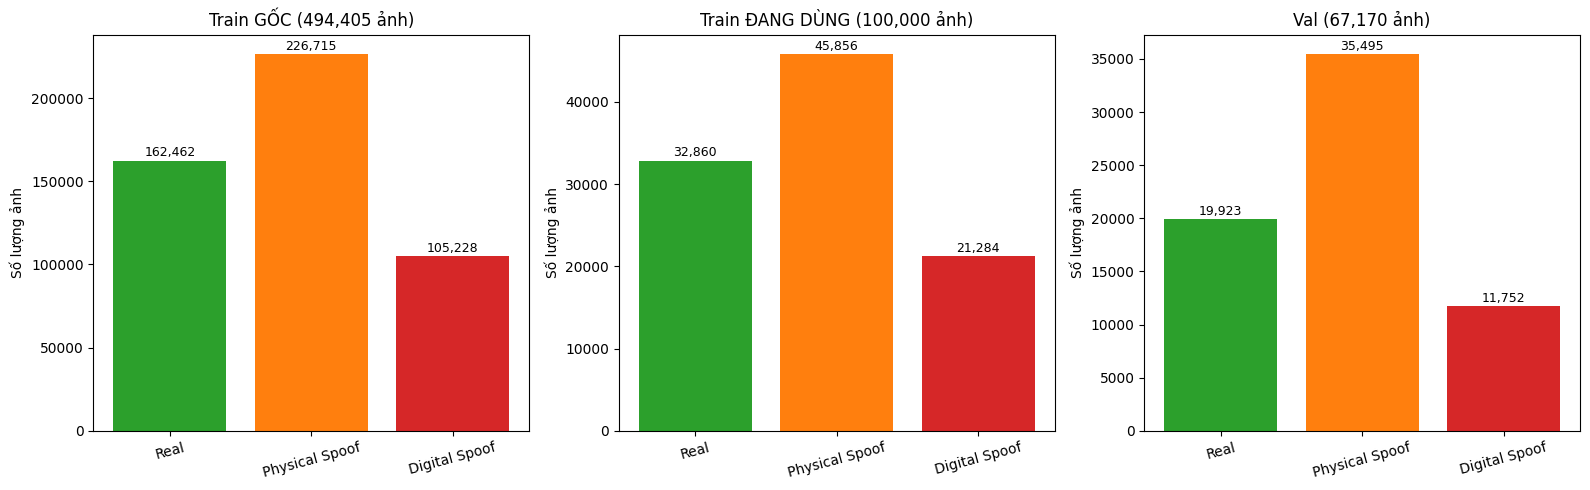

Train (gốc):         {0: 162462, 1: 226715, 2: 105228}
Train (đang dùng):   {0: 32860, 1: 45856, 2: 21284}
Val:                 {0: 19923, 1: 35495, 2: 11752}


In [11]:
# Cell 3.5: Thống kê phân bố 3 class (Real / Physical Spoof / Digital Spoof)

def count_classes_from_dict(data_dict, keys):
    counts = {0: 0, 1: 0, 2: 0}
    for k in keys:
        counts[_label_of(data_dict[k])] += 1
    return counts

class_names = ["Real", "Physical Spoof", "Digital Spoof"]
colors = ["#2ca02c", "#ff7f0e", "#d62728"]

# Train ĐẦY ĐỦ (toàn bộ 494K+ ảnh gốc, trước khi giới hạn TRAIN_SAMPLE_SIZE)
train_counts_full = count_classes_from_dict(train_dataset_full.data, train_dataset_full.keys)

# Train THỰC TẾ ĐANG DÙNG để train (sau khi giới hạn, nếu có)
if isinstance(train_dataset, torch.utils.data.Subset):
    used_keys = [train_dataset_full.keys[i] for i in train_dataset.indices]
    train_counts_used = count_classes_from_dict(train_dataset_full.data, used_keys)
else:
    train_counts_used = train_counts_full

val_counts = count_classes_from_dict(val_dataset.data, val_dataset.keys)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, counts, title in zip(
    axes,
    [train_counts_full, train_counts_used, val_counts],
    [f"Train GỐC ({sum(train_counts_full.values()):,} ảnh)",
     f"Train ĐANG DÙNG ({sum(train_counts_used.values()):,} ảnh)",
     f"Val ({sum(val_counts.values()):,} ảnh)"]
):
    values = [counts[0], counts[1], counts[2]]
    bars = ax.bar(class_names, values, color=colors)
    ax.set_title(title)
    ax.set_ylabel("Số lượng ảnh")
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars, values):
        ax.annotate(f"{v:,}", xy=(b.get_x() + b.get_width()/2, v),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("data_distribution.png", dpi=150)
plt.show()

print("Train (gốc):        ", train_counts_full)
print("Train (đang dùng):  ", train_counts_used)
print("Val:                ", val_counts)


In [ ]:
# 📌 Cell 3.5: Hiển thị 5 Ảnh Mẫu Cho Mỗi Lớp (Real, Physical Spoof, Digital Spoof)

import matplotlib.pyplot as plt
import albumentations as A

# Transform nhẹ chỉ resize để giữ nguyên màu sắc nguyên bản (RGB) khi vẽ đồ thị
vis_transform = A.Compose([
    A.Resize(224, 224)
])

vis_dataset = CelebASpoof3ClassDataset(DATA_ROOT, VAL_JSON, transform=vis_transform)

class_names = {
    0: "Real (Class 0)",
    1: "Physical Spoof (Class 1 - Print)",
    2: "Digital Spoof (Class 2 - Screen)"
}

samples_per_class = {0: [], 1: [], 2: []}
needed = 5

print("🔍 Đang tìm kiếm và nạp 5 ảnh mẫu cho mỗi lớp...")
for idx in range(len(vis_dataset)):
    if all(len(samples_per_class[c]) >= needed for c in [0, 1, 2]):
        break
    
    img, label = vis_dataset[idx]
    label_int = int(label)
    
    if len(samples_per_class[label_int]) < needed:
        samples_per_class[label_int].append(img)

# Vẽ lưới 3 hàng (3 lớp) x 5 cột (5 ảnh/lớp)
fig, axes = plt.subplots(3, needed, figsize=(15, 9))

for row_idx, cls_id in enumerate([0, 1, 2]):
    images = samples_per_class[cls_id]
    for col_idx in range(needed):
        ax = axes[row_idx, col_idx]
        if col_idx < len(images):
            ax.imshow(images[col_idx])
            ax.set_title(f"{class_names[cls_id]} #{col_idx+1}", fontsize=9, fontweight='bold')
        ax.axis('off')

plt.suptitle("📸 5 Ảnh Mẫu Cho Mỗi Lớp Trong Dataset CelebA-Spoof", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# 📌 Cell 4: Model MobileNetV3-Large Setup

In [ ]:
# 📌 Cell 4: Model Setup, Loss Function & Optimizer (Đã Tối Ưu Tốt Nhất)

class AntiSpoofMobileNetV3(nn.Module):
    def __init__(self, dropout_rate=0.5, num_classes=3):
        """
        MobileNetV3-Large cho Anti-Spoofing 3 lớp (0: Real, 1: Physical Spoof, 2: Screen Spoof).
        Tăng dropout_rate lên 0.5 để triệt tiêu Overfitting.
        """
        super(AntiSpoofMobileNetV3, self).__init__()
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        backbone = models.mobilenet_v3_large(weights=weights)

        self.features = backbone.features
        self.avgpool = backbone.avgpool
        in_features = backbone.classifier[0].in_features

        # Classifier Head, 3 class
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 1280),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AntiSpoofMobileNetV3(dropout_rate=0.5, num_classes=3).to(device)

# --- Loss Function: Phạt nặng hơn khi nhận nhầm Mặt Thật (Class 0) thành Giả -> Giảm BPCER ---
# Class 0 (Real): Trọng số 2.0 | Class 1 (Physical): Trọng số 1.0 | Class 2 (Screen): Trọng số 1.0
class_weights = torch.tensor([1, 1, 1]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# --- Optimizer: Differential Learning Rate + Weight Decay ---
# Backbone học chậm (1e-4) để bảo toàn tri thức ImageNet
# Classifier Head học nhanh hơn (1e-3)
optimizer = torch.optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-3)

# --- Learning Rate Scheduler & AMP Scaler ---
# Chú ý: Đặt T_max bằng đúng số epoch thực tế bạn chọn train (ví dụ: 10)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')

print(f"✅ Model AntiSpoofMobileNetV3 đã khởi tạo trên: {device}")
print(f"✅ Loss Function: CrossEntropy (Class Weights = {class_weights.tolist()}, Label Smoothing = 0.1)")
print(f"✅ Optimizer: AdamW (Backbone LR: 1e-4, Head LR: 1e-3, Weight Decay: 1e-3)")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 255MB/s]

✅ Model AntiSpoofMobileNetV3 đã khởi tạo trên: cpu
✅ Loss Function: CrossEntropy (Class Weights = [1.5, 0.75, 1.600000023841858], Label Smoothing = 0.1)
✅ Optimizer: AdamW (Backbone LR: 1e-4, Head LR: 1e-3, Weight Decay: 1e-3)



/tmp/ipykernel_58/3420550616.py:52: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler('cuda')


Một đoạn nhỏ của train_label.json

In [7]:
import json
with open(TRAIN_JSON, 'r') as f:
    data = json.load(f)

keys = list(data.keys())
print("Tổng số ảnh:", len(keys))
print("--- 2 key đầu tiên ---")
for k in keys[:2]:
    print("KEY:", k)
    print("VALUE (type={}, len={}):".format(type(data[k]), len(data[k]) if isinstance(data[k], (list, dict)) else "N/A"))
    print(data[k])
    print()

Tổng số ảnh: 494405
--- 2 key đầu tiên ---
KEY: Data/train/2623/live/000000.jpg
VALUE (type=<class 'list'>, len=44):
[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]

KEY: Data/train/5489/spoof/000001.jpg
VALUE (type=<class 'list'>, len=44):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 1, 1, 1]



Nội dung 1 file _BB.txt mẫu

In [8]:
import os
sample_key = keys[0]
img_path = os.path.join(DATA_ROOT, sample_key)
bb_path = os.path.splitext(img_path)[0] + "_BB.txt"

print("Ảnh có tồn tại không:", os.path.exists(img_path))
print("BB.txt có tồn tại không:", os.path.exists(bb_path))
if os.path.exists(bb_path):
    print("Nội dung BB.txt:")
    print(open(bb_path).read())

# Tiện thể lấy luôn kích thước ảnh thật
import cv2
img = cv2.imread(img_path)
print("Kích thước ảnh thật (H, W):", img.shape[:2] if img is not None else "Không đọc được ảnh")

Ảnh có tồn tại không: True
BB.txt có tồn tại không: True
Nội dung BB.txt:
77 11 48 59 0.9962846

Kích thước ảnh thật (H, W): (550, 500)


# 📌 Cell 5: Training Loop

In [13]:
# Cell 5: Train Model (checkpoint/resume mỗi epoch + hỗ trợ resume qua Kaggle "Add Data")
#
# CÁCH DÙNG QUA NHIỀU SESSION KAGGLE (do giới hạn ~12h/session):
#   1) Chạy notebook bằng "Save Version" -> "Save & Run All (Commit)".
#   2) Mở version MỚI -> "Add Input" -> "Notebook Output Files" (hoặc 1 Dataset chứa checkpoint).
#   3) Điền path vào CHECKPOINT_INPUT_PATH / BEST_MODEL_INPUT_PATH bên dưới -> resume đúng epoch.

import shutil

CHECKPOINT_PATH = "checkpoint_last.pth"          # nơi LƯU checkpoint của lần chạy này (luôn ghi vào /kaggle/working)
BEST_MODEL_PATH = "best_mnv3_large_3class.pth"

# Nếu đã "Add Data" output/dataset chứa checkpoint_last.pth cũ, điền path vào đây. Để "" nếu chưa có.
CHECKPOINT_INPUT_PATH = "/kaggle/input/checkpoint/results/checkpoint_last.pth"

# Tương tự cho best_mnv3_large_3class.pth (copy trực tiếp, không phụ thuộc checkpoint có best_model_state hay không).
BEST_MODEL_INPUT_PATH = "/kaggle/input/checkpoint/results/best_mnv3_large_3class.pth"

epochs = 20
start_epoch = 0
best_val_acc = 0.0
best_model_state = None  # state_dict của epoch có val_acc CAO NHẤT (khác model_state = epoch GẦN NHẤT)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# --- Xác định nguồn checkpoint để resume ---
resume_source = None
if os.path.exists(CHECKPOINT_PATH):
    resume_source = CHECKPOINT_PATH
elif CHECKPOINT_INPUT_PATH and os.path.exists(CHECKPOINT_INPUT_PATH):
    shutil.copy(CHECKPOINT_INPUT_PATH, CHECKPOINT_PATH)  # /kaggle/input read-only -> copy về working
    resume_source = CHECKPOINT_PATH

if resume_source is not None:
    ckpt = torch.load(resume_source, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    scaler.load_state_dict(ckpt["scaler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]
    history = ckpt["history"]
    best_model_state = ckpt.get("best_model_state", None)  # có thể thiếu nếu checkpoint từ bản cũ hơn
    print(f"✅ Tìm thấy checkpoint ({resume_source}) -> resume từ epoch {start_epoch + 1}/{epochs} "
          f"(best_val_acc hiện tại: {best_val_acc:.4f})")

    # Đảm bảo BEST_MODEL_PATH tồn tại NGAY trong /kaggle/working của phiên này (Cell 6/7 cần).
    # Ưu tiên: (1) đã có sẵn -> giữ nguyên | (2) copy từ BEST_MODEL_INPUT_PATH
    #          (3) khôi phục từ best_model_state trong checkpoint | (4) tạm dùng model_state gần nhất
    if not os.path.exists(BEST_MODEL_PATH):
        if BEST_MODEL_INPUT_PATH and os.path.exists(BEST_MODEL_INPUT_PATH):
            shutil.copy(BEST_MODEL_INPUT_PATH, BEST_MODEL_PATH)
            print(f"   -> Đã copy {BEST_MODEL_PATH} trực tiếp từ {BEST_MODEL_INPUT_PATH}.")
        elif best_model_state is not None:
            torch.save(best_model_state, BEST_MODEL_PATH)
            print(f"   -> Đã khôi phục lại {BEST_MODEL_PATH} từ checkpoint.")
        else:
            torch.save(ckpt["model_state"], BEST_MODEL_PATH)
            print(f"   ⚠️ Không có nguồn best model nào -> tạm ghi {BEST_MODEL_PATH} bằng weight epoch gần nhất.")
else:
    print("Không có checkpoint cũ -> train từ epoch 1")

if start_epoch >= epochs:
    print(f"🎉 Đã train đủ {epochs} epoch từ trước, không cần train thêm.")

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f"{running_loss/total:.4f}", 'acc': f"{correct/total:.4f}"})

    scheduler.step()
    history["train_loss"].append(running_loss / total)
    history["train_acc"].append(correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    history["val_loss"].append(val_loss / val_total)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()
        torch.save(best_model_state, BEST_MODEL_PATH)

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "best_model_state": best_model_state,
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history,
    }, CHECKPOINT_PATH)

epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker='o')
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker='o')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker='o')
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc", marker='o')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Validation Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

print(f"--> Best Val Acc: {best_val_acc:.4f} (checkpoint: {BEST_MODEL_PATH})")
print(f"--> Đã train xong tới epoch {len(history['train_loss'])}/{epochs}. "
      f"Nếu chưa đủ {epochs}, hãy Commit rồi Add Data output ở version tiếp theo để resume.")


Không có checkpoint cũ -> train từ epoch 1


Epoch 1/20 [Train]:   0%|          | 0/782 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_58/1816121622.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 1/20 [Train]:   0%|          | 3/782 [00:43<3:09:28, 14.59s/it, loss=1.0037, acc=0.4375]


KeyboardInterrupt: 

# 📌 Cell 5.5: Cross-Dataset Loader (LCC-FASD)

In [11]:
# Cell 5.5: LCC-FASD Dataset & DataLoader (dùng cho Cross-Test ở Cell 6)
#
# Cấu trúc thực tế của bộ LCC-FASD trên Kaggle (mirror aleksandrpikul222/lcc-fasd):
#   - Toàn bộ ảnh nằm PHẲNG trong 1 thư mục, KHÔNG chia real/spoof theo thư mục con.
#   - Nhãn được xác định qua 4 file danh sách (đã verify số dòng khớp 100% với tổng số ảnh):
#       CLIENT_TRAIN.txt   (1553 dòng) -> Real
#       CLIENT_TEST.txt    (389 dòng)  -> Real
#       IMPOSTER_TRAIN.txt (13508 dòng)-> Spoof
#       IMPOSTER_TEST.txt  (3377 dòng) -> Spoof
#   ("CLIENT" = người dùng thật, "IMPOSTER" = kẻ giả mạo -> thuật ngữ chuẩn sinh trắc học)

class LCCFASDDataset(Dataset):
    def __init__(self, root_dir, list_files, transform=None):
        """
        root_dir: thư mục gốc chứa ảnh LCC_FASD
        list_files: list các tuple (tên_file_txt, label) -> label: 0 = Real, 1 = Spoof
        """
        self.root_dir = root_dir
        self.samples = []  # list các (tên_file_ảnh, label)

        for txt_name, label in list_files:
            txt_path = os.path.join(root_dir, txt_name)
            with open(txt_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    # Các dòng trong .txt là full path cũ (vd '/kaggle/input/lcc-fasd/LCC_FASD/xxx.png')
                    # -> chỉ lấy TÊN FILE, ghép lại với root_dir hiện tại (path có thể đã đổi)
                    filename = os.path.basename(line)
                    self.samples.append((filename, label))

        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        img_path = os.path.join(self.root_dir, filename)
        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(label, dtype=torch.long)


LCC_ROOT = "/kaggle/input/datasets/aleksandrpikul222/lcc-fasd/LCC_FASD"

# Dùng TOÀN BỘ ảnh (cả train+test gốc của LCC_FASD) làm tập Cross-Test,
# vì model KHÔNG được train trên bộ này -> train/test split gốc của nó không có ý nghĩa với ta,
# gộp lại cho tập test lớn hơn, đánh giá ổn định hơn.
lcc_dataset = LCCFASDDataset(
    LCC_ROOT,
    list_files=[
        ("CLIENT_TRAIN.txt", 0),
        ("CLIENT_TEST.txt", 0),
        ("IMPOSTER_TRAIN.txt", 1),
        ("IMPOSTER_TEST.txt", 1),
    ],
    transform=val_transform  # tái sử dụng transform (resize 224 + normalize CelebA mean/std) đã dùng cho val_loader
)

lcc_loader = DataLoader(lcc_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

n_real = sum(1 for _, l in lcc_dataset.samples if l == 0)
n_spoof = sum(1 for _, l in lcc_dataset.samples if l == 1)
print(f"--> LCC-FASD Loaded: {len(lcc_dataset)} mẫu (Real: {n_real}, Spoof: {n_spoof})")


--> LCC-FASD Loaded: 18827 mẫu (Real: 1942, Spoof: 16885)


# 📌 Cell 6: ⭐ DUAL TESTING SCRIPT (Đánh giá đồng thời Intra-Test & Cross-Test)

In [ ]:
# Cell 6: Dual Testing Script (Intra-Dataset + Cross-Dataset Evaluation)

def evaluate_loader(model, loader, name="Dataset"):
    model.eval()
    y_true = []
    y_scores = []
    y_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Evaluating {name}"):
            images = images.to(device)
            outputs = model(images)

            real_logit = outputs[:, 0]
            spoof_logit = torch.max(outputs[:, 1:], dim=1)[0]
            logit_diff = (real_logit - spoof_logit).cpu().numpy()

            preds = (logit_diff < 0.0).astype(int)  # 0: Real, 1: Spoof
            binary_labels = (labels > 0).long().numpy()  # 0: Real, 1: Spoof

            y_true.extend(binary_labels)
            y_scores.extend(-logit_diff)
            y_preds.extend(preds)

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    y_preds = np.array(y_preds)

    acc = accuracy_score(y_true, y_preds)
    cm = confusion_matrix(y_true, y_preds)
    TN, FP, FN, TP = cm.ravel()

    APCER = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    BPCER = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    ACER = (APCER + BPCER) / 2.0
    try:
        auc = roc_auc_score(y_true, y_scores)
    except Exception:
        auc = 0.0

    return {
        "Accuracy": acc * 100,
        "APCER": APCER * 100,
        "BPCER": BPCER * 100,
        "ACER/HTER": ACER * 100,
        "AUC": auc * 100
    }

# Nạp model checkpoint tốt nhất.
# Nếu vì lý do nào đó BEST_MODEL_PATH không tồn tại trong /kaggle/working của phiên này
# -> dùng tạm weight đang có sẵn trong biến `model` (đã được Cell 5 load/resume) thay vì crash.
try:
    model.load_state_dict(torch.load("best_mnv3_large_3class.pth"))
    print("--> Đã nạp best_mnv3_large_3class.pth")
except FileNotFoundError:
    print("⚠️ Không tìm thấy best_mnv3_large_3class.pth trong phiên này "
          "-> dùng tạm weight hiện có trong biến `model` để đánh giá.")

intra_results = evaluate_loader(model, val_loader, name="CelebA-Spoof (Intra-Test)")
cross_results = evaluate_loader(model, lcc_loader, name="LCC-FASD (Cross-Test)")

metrics = ["Accuracy", "APCER", "BPCER", "ACER/HTER", "AUC"]
intra_vals = [intra_results[m] for m in metrics]
cross_vals = [cross_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, intra_vals, width, label="Intra (CelebA-Spoof)")
bars2 = ax.bar(x + width/2, cross_vals, width, label="Cross (LCC-FASD)")

ax.set_ylabel("%")
ax.set_title("So sánh kết quả đánh giá: Intra-Test vs Cross-Test")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("dual_testing_comparison.png", dpi=150)
plt.show()


# 📌 Cell 7: Export ONNX

In [ ]:
# Cell 7: Export ONNX (Tự động khởi tạo model & nạp trọng số .pth kể cả khi chạy độc lập)
!pip install -q onnxscript

# 1. Tự động khởi tạo device & model kiến trúc AntiSpoofMobileNetV3 nếu chưa chạy Cell 4
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "AntiSpoofMobileNetV3" not in globals():
    class AntiSpoofMobileNetV3(nn.Module):
        def __init__(self, dropout_rate=0.5, num_classes=3):
            super(AntiSpoofMobileNetV3, self).__init__()
            weights = models.MobileNet_V3_Large_Weights.DEFAULT
            backbone = models.mobilenet_v3_large(weights=weights)
            self.features = backbone.features
            self.avgpool = backbone.avgpool
            in_features = backbone.classifier[0].in_features
            self.classifier = nn.Sequential(
                nn.Linear(in_features, 1280),
                nn.Hardswish(inplace=True),
                nn.Dropout(p=dropout_rate),
                nn.Linear(1280, num_classes)
            )
        def forward(self, x):
            x = self.features(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)
            x = self.classifier(x)
            return x

if "model" not in globals():
    model = AntiSpoofMobileNetV3(dropout_rate=0.5, num_classes=3).to(device)

# 2. Đường dẫn file trọng số .pth từ Kaggle Input (Add Data)
MODEL_INPUT_PATH = "/kaggle/input/datasets/thitrnduy/checkpoint/results/best_mnv3_large_3class.pth"

pth_candidates = [
    "best_mnv3_large_3class.pth",        # Ưu tiên 1: File vừa train trong /kaggle/working
    MODEL_INPUT_PATH,                     # Ưu tiên 2: File từ Kaggle Input (Add Data)
    BEST_MODEL_INPUT_PATH if "BEST_MODEL_INPUT_PATH" in globals() else "" # Ưu tiên 3: Biến Cell 5
]

loaded = False
for path in pth_candidates:
    if path and os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path, map_location=device))
            print(f"✅ Đã nạp thành công trọng số từ: '{path}'")
            loaded = True
            break
        except Exception as e:
            print(f"⚠️ Lỗi nạp trọng số từ '{path}': {e}")

if not loaded:
    print("⚠️ Không tìm thấy file .pth ở các đường dẫn trên -> Export bằng trọng số hiện tại của .")

model.eval()
dummy_input = torch.randn(1, 3, 224, 224, device=device)
onnx_filename = "mnv3_large_3class_best.onnx"

try:
    torch.onnx.export(
        model,
        dummy_input,
        onnx_filename,
        export_params=True,
        opset_version=14,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        },
        dynamo=False
    )
except Exception:
    torch.onnx.export(
        model,
        dummy_input,
        onnx_filename,
        export_params=True,
        opset_version=14,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )

onnx_model = onnx.load(onnx_filename)
onnx.checker.check_model(onnx_model)
print("🎉 Successfully exported 3-class ONNX model:", onnx_filename)
